In [ ]:
# Objectives
This project analyzes clinical and demographic factors associated with survival in 
lymphoma patients using descriptive statistics, Chi-square tests, and logistic
regression
## Data Loading
- Imported the CSV dataset
- Reviewed the dataset structure 
- Examined the firt five records 

In [5]:
import csv
import pandas as pd
df = pd.read_csv("raw_lymphome.csv", encoding="cp1252")
df.head()

,id,age,sex,visit_reason,année,date,score_OMS,adp_superficielle,adp_profonde,adp_mediastinale,...,lympho,pq,evolutivite bio,treatment,protocole,number_chemo,response,tolerance,evolution,death reason
0,1,34,m,refere lnh,2017,8/18/2017,1,non,non,non,...,1060,813000,Ab,oui,RCHOP,8.0,rechute,bne,sous ttt,NaN
1,2,56,f,adp,2015,9/10/2012,1,oui,non,non,...,1317,153000,Ab,oui,CHOP,6.0,B,NaN,surv,pv
2,3,31,f,refere lnh,2017,1/12/2017,1,oui,non,non,...,2400,184000,Ab,oui,CHOP,6.0,B,bne,surv,NaN
3,4,64,m,refere lnh,2017,5/25/2017,2,non,non,non,...,2000,209000,Bb,oui,CHOP,3.0,B,bne,surv,pv
4,5,25,f,masse abdo,2018,1/19/2018,3,non,oui,non,...,3370,381000,Bb,oui,RCHOP,4.0,B,bne,sous ttt,NaN


In [6]:
df.shape

(69, 32)

In [7]:
df.columns

Index(['id', 'age', 'sex', 'visit_reason', 'année', 'date', 'score_OMS',
       'adp_superficielle', 'adp_profonde', 'adp_mediastinale',
       'hepatomegalie', 'adp_size', 'cytologie', 'histologie', 'histochimie',
       'HIV', 'Hépatite', 'Ann Arbor', 'ldh', 'hb', 'gb', 'pnn', 'lympho',
       'pq', 'evolutivite bio', 'treatment', 'protocole', 'number_chemo',
       'response', 'tolerance', 'evolution', 'death reason'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 69 non-null     int64  
 1   age                69 non-null     int64  
 2   sex                69 non-null     object 
 3   visit_reason       69 non-null     object 
 4   année              69 non-null     int64  
 5   date               69 non-null     object 
 6   score_OMS          69 non-null     int64  
 7   adp_superficielle  69 non-null     object 
 8   adp_profonde       69 non-null     object 
 9   adp_mediastinale   69 non-null     object 
 10  hepatomegalie      69 non-null     object 
 11  adp_size           69 non-null     int64  
 12  cytologie          69 non-null     object 
 13  histologie         69 non-null     object 
 14  histochimie        69 non-null     object 
 15  HIV                69 non-null     object 
 16  Hépatite           69 non-nu

In [ ]:
## Data Cleaning
- Identified and assessed missing values. 
- Renamed columns.
- Converted date variables were converted to datetime format. 
- Cleaned and recoded categorical variables.

In [11]:
df.isna().sum()

id                    0
age                   0
sex                   0
visit_reason          0
année                 0
date                  0
score_OMS             0
adp_superficielle     0
adp_profonde          0
adp_mediastinale      0
hepatomegalie         0
adp_size              0
cytologie             0
histologie            0
histochimie           0
HIV                   0
Hépatite              0
Ann Arbor             0
ldh                   0
hb                    0
gb                    0
pnn                   1
lympho                0
pq                    0
evolutivite bio       0
treatment             0
protocole            11
number_chemo          2
response             13
tolerance            16
evolution             0
death reason         28
dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
df.isna().sum().sort_values(ascending=False)

death reason         28
tolerance            16
response             13
protocole            11
number_chemo          2
pnn                   1
id                    0
age                   0
adp_profonde          0
adp_mediastinale      0
sex                   0
visit_reason          0
année                 0
date                  0
score_OMS             0
adp_superficielle     0
HIV                   0
histochimie           0
histologie            0
cytologie             0
adp_size              0
hepatomegalie         0
ldh                   0
Hépatite              0
pq                    0
lympho                0
gb                    0
hb                    0
Ann Arbor             0
treatment             0
evolutivite bio       0
evolution             0
dtype: int64

In [14]:
missing = (df.isna().sum()/len(df) * 100).round(2)
missing.sort_values(ascending=False)

death reason         40.58
tolerance            23.19
response             18.84
protocole            15.94
number_chemo          2.90
pnn                   1.45
id                    0.00
age                   0.00
adp_profonde          0.00
adp_mediastinale      0.00
sex                   0.00
visit_reason          0.00
année                 0.00
date                  0.00
score_OMS             0.00
adp_superficielle     0.00
HIV                   0.00
histochimie           0.00
histologie            0.00
cytologie             0.00
adp_size              0.00
hepatomegalie         0.00
ldh                   0.00
Hépatite              0.00
pq                    0.00
lympho                0.00
gb                    0.00
hb                    0.00
Ann Arbor             0.00
treatment             0.00
evolutivite bio       0.00
evolution             0.00
dtype: float64

In [15]:
df = df.rename(columns={"protocole": "chemo_protocol","adp_profonde": "deep_adp",
                       "adp_mediastinale": "mediastinum_adp", 
                        "année": "firsvisit_year", 
                        "adp_superficielle": "superficial_adp",
                       "histochimie": "histochemistry", 
                       "histologie": "histology", "cytologie": "cytology",
                       "hepatomegalie": "hepatomegaly", "Hépatite": "hepatisis",
                       "pq": "platelets", "lympho": "lymphocyte",
                       "gb": "white_cells", "hb": "hemoglobin", 
                       "evolutivite bio": "biology_evolution",
                       "score_OMS": "who_score", "ldh": "LDH", "HIV": "hiv",
                       "Ann Arbor": "ann_arbor_stage", "pnn": "neutrophils",
                       "response": "treatment_response",
                       "tolerance": "treatment_tolerance",
                       "evolution": "outcome", "death reason": "death_reason"})

In [16]:
df.columns

Index(['id', 'age', 'sex', 'visit_reason', 'firsvisit_year', 'date',
       'who_score', 'superficial_adp', 'deep_adp', 'mediastinum_adp',
       'hepatomegaly', 'adp_size', 'cytology', 'histology', 'histochemistry',
       'hiv', 'hepatisis', 'ann_arbor_stage', 'LDH', 'hemoglobin',
       'white_cells', 'neutrophils', 'lymphocyte', 'platelets',
       'biology_evolution', 'treatment', 'chemo_protocol', 'number_chemo',
       'treatment_response', 'treatment_tolerance', 'outcome', 'death_reason'],
      dtype='object')

In [17]:
df["date"] = pd.to_datetime(df["date"])

In [18]:
df["ann_arbor_stage"] = df["ann_arbor_stage"].replace({1: "I",
2: "II", 3: "III", 4: "IV"})

In [19]:
df["histology"] = df["histology"].replace({"diffus pttes c": "SLL",
                                          "LNH à GCD": "DLBCL",
                                          "lymphome": "others_lymphoma"})

In [20]:
df["treatment_tolerance"] = df["treatment_tolerance"].replace(
    {"bne": "Good", "m": "Bad"})

In [21]:
df["treatment_response"] = df["treatment_response"].replace(
    {"B": "Complete Response", "N": "No Response",
      "rechute": "Relapse"}).fillna("Unknown")

In [22]:
df["outcome"] = df["outcome"].replace(
    {"surv": "Alive", "pv": "Lost to Follow-up",
      "DC": "Deceased", "sous ttt": "On Treatment"})

In [23]:
df["sex"] = df["sex"].replace({"m": "Male", "f": "Female"})

In [24]:
df["date"].dtypes

dtype('<M8[ns]')

In [ ]:
# Descriptive analysis
 - Age Summary
 - Sex Distribution
 - Histology Distribution
 - Ann Arbor Stage Distribution 
 - Treatement Response Distribution
 - Treatment Tolerance Distribution
 - Outcome Distribution

In [27]:
## Age Statistics 
df["age"].describe()

count    69.000000
mean     42.739130
std      15.902878
min      15.000000
25%      31.000000
50%      45.000000
75%      57.000000
max      69.000000
Name: age, dtype: float64

In [28]:
## Sex Distribution
df["sex"].value_counts()
(df["sex"].value_counts(normalize=True)* 100).round(1)

sex
Male      65.2
Female    34.8
Name: proportion, dtype: float64

In [29]:
## Histology Distribution
(df["histology"].value_counts(normalize=True)*100).round(1)

histology
SLL                49.3
DLBCL              39.1
others_lymphoma    11.6
Name: proportion, dtype: float64

In [30]:
## Ann-Arbor Stage Distribution
(df["ann_arbor_stage"].value_counts(normalize=True)* 100).sort_index().round(1)

ann_arbor_stage
I      10.1
II     15.9
III    60.9
IV     13.0
Name: proportion, dtype: float64

In [31]:
(df["treatment_response"].value_counts(normalize=True)* 100).round(1)

treatment_response
Complete Response    60.9
Unknown              18.8
No Response          11.6
Relapse               8.7
Name: proportion, dtype: float64

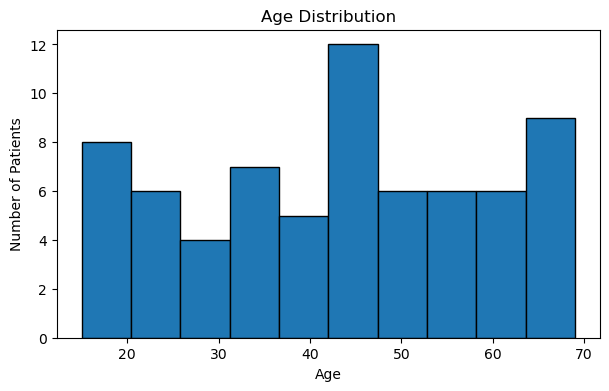

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.hist(df["age"], bins=10, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

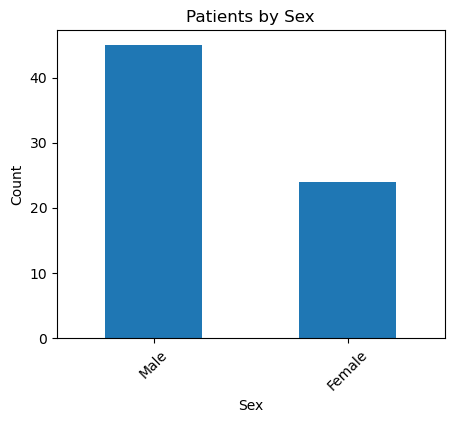

In [33]:
df["sex"].value_counts().plot(kind="bar", figsize=(5,4))
plt.title("Patients by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

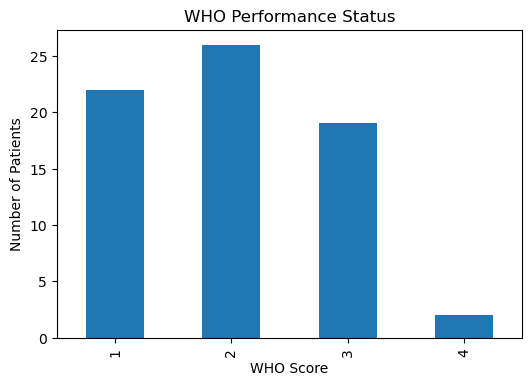

In [34]:
df["who_score"].value_counts().sort_index().plot(
    kind="bar", figsize=(6,4))
plt.title("WHO Performance Status")
plt.xlabel("WHO Score")
plt.ylabel("Number of Patients")
plt.show()

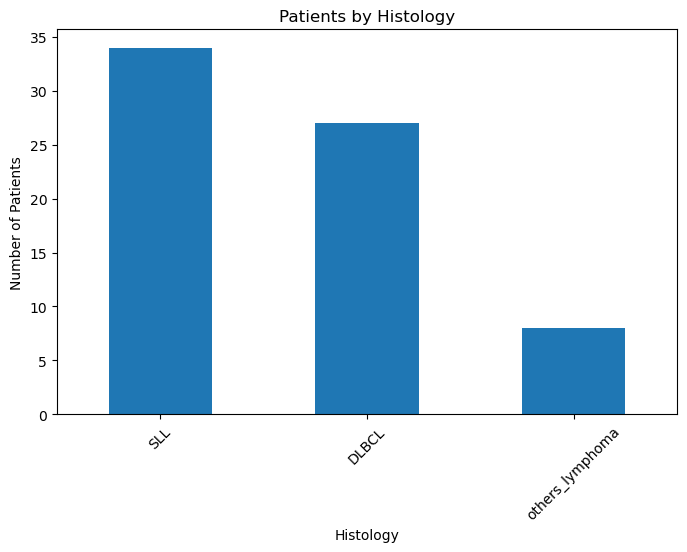

In [35]:
df["histology"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Patients by Histology")
plt.xlabel("Histology")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

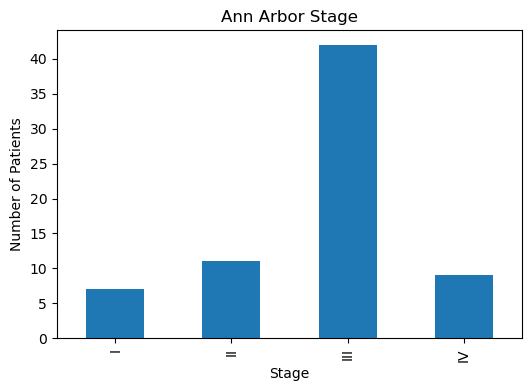

In [36]:
df["ann_arbor_stage"].value_counts().reindex(["I", "II", "III", "IV"]).plot(
    kind="bar", figsize=(6,4))
plt.title("Ann Arbor Stage")
plt.xlabel("Stage")
plt.ylabel("Number of Patients")

plt.show()

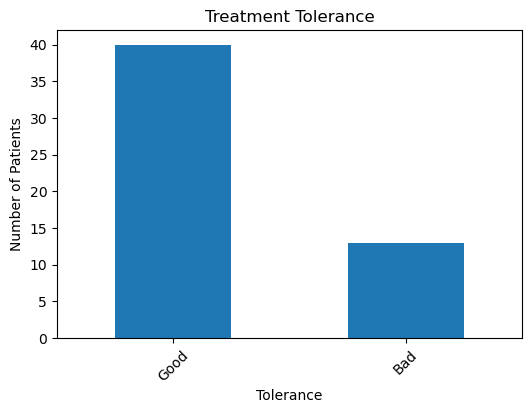

In [37]:
df["treatment_tolerance"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Treatment Tolerance")
plt.xlabel("Tolerance")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

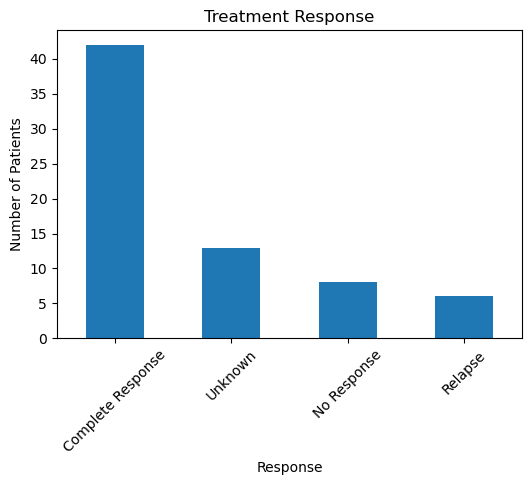

In [38]:
df["treatment_response"].value_counts().plot(
    kind="bar", figsize=(6,4))
plt.title("Treatment Response")
plt.xlabel("Response")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

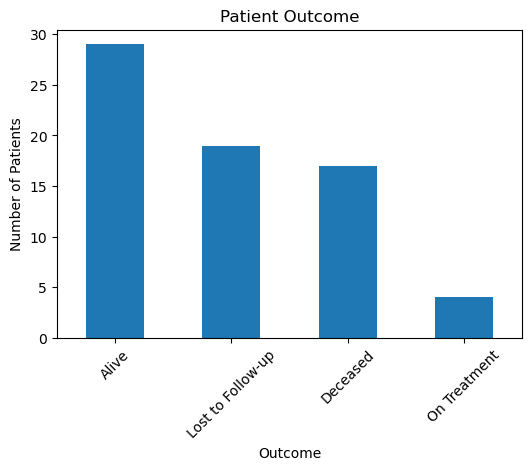

In [39]:
df["outcome"].value_counts().plot(
     kind="bar", figsize=(6,4))
plt.title("Patient Outcome")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Bivariate analysis
 - Ann Arbor Stage vs Treatment Response
 - Histology vs Treatment Response
 - Treatment response vs Outcome
 - Treatment tolerance vs Outcome

In [89]:
pd.crosstab(df["ann_arbor_stage"], df["treatment_response"],
           normalize="index").round(2) * 100

treatment_response,Complete Response,No Response,Relapse,Unknown
ann_arbor_stage,,,,
I,57.0,0.0,14.0,29.0
II,64.0,0.0,18.0,18.0
III,69.0,12.0,7.0,12.0
IV,22.0,33.0,0.0,44.0


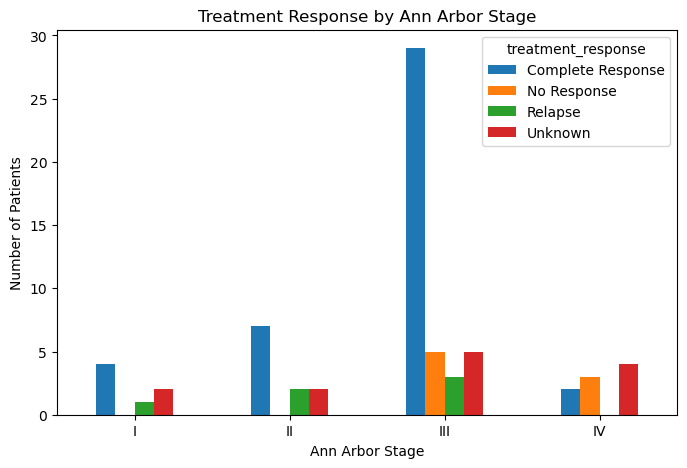

In [90]:
pd.crosstab(df["ann_arbor_stage"], df["treatment_response"]).plot(
    kind="bar", figsize=(8,5))
plt.title("Treatment Response by Ann Arbor Stage")
plt.xlabel("Ann Arbor Stage")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

In [91]:
pd.crosstab(df["histology"], df["treatment_response"],
            normalize="index").round(2) * 100

treatment_response,Complete Response,No Response,Relapse,Unknown
histology,,,,
DLBCL,59.0,15.0,4.0,22.0
SLL,62.0,9.0,12.0,18.0
others_lymphoma,62.0,12.0,12.0,12.0


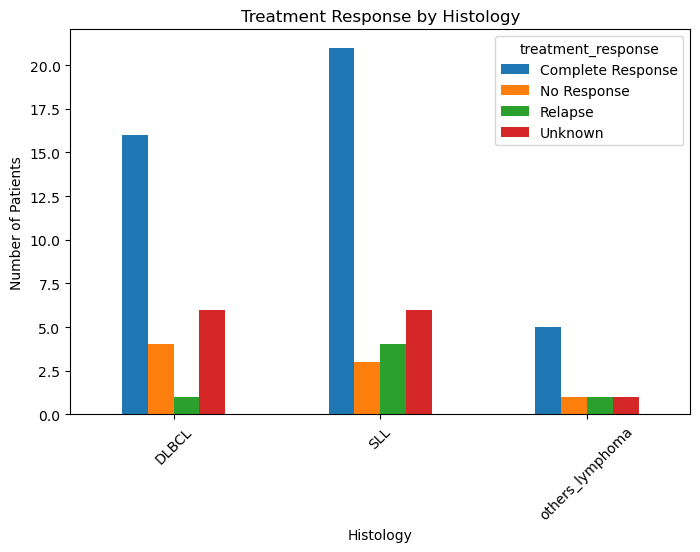

In [92]:
pd.crosstab(df["histology"], df["treatment_response"]).plot(
    kind="bar", figsize=(8,5))
plt.title("Treatment Response by Histology")
plt.xlabel("Histology")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

In [93]:
pd.crosstab(df["treatment_response"], df["outcome"],
            normalize="index").round(2) * 100

outcome,Alive,Deceased,Lost to Follow-up,On Treatment
treatment_response,,,,
Complete Response,55.0,7.0,31.0,7.0
No Response,0.0,88.0,12.0,0.0
Relapse,50.0,33.0,0.0,17.0
Unknown,23.0,38.0,38.0,0.0


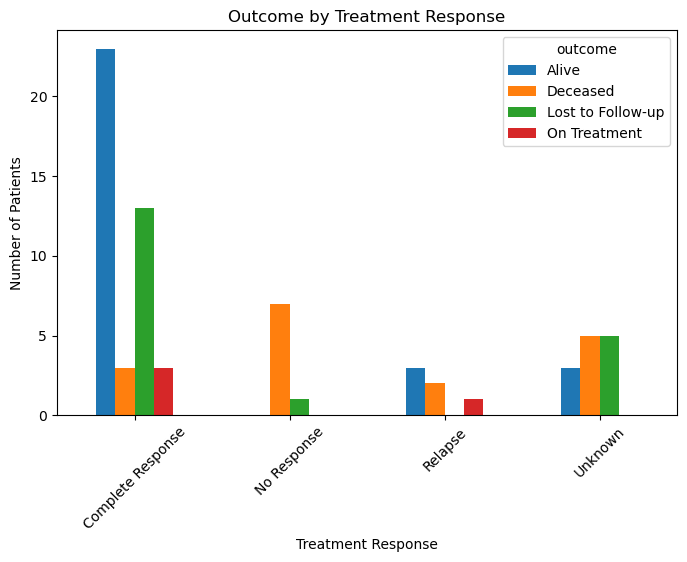

In [94]:
pd.crosstab(df["treatment_response"], df["outcome"]).plot(
            kind="bar", figsize=(8,5))
plt.title("Outcome by Treatment Response")
plt.xlabel("Treatment Response")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

In [95]:
pd.crosstab(df["treatment_tolerance"], df["outcome"],
            normalize="index").round(2) * 100

outcome,Alive,Deceased,Lost to Follow-up,On Treatment
treatment_tolerance,,,,
Bad,15.0,54.0,31.0,0.0
Good,57.0,10.0,22.0,10.0


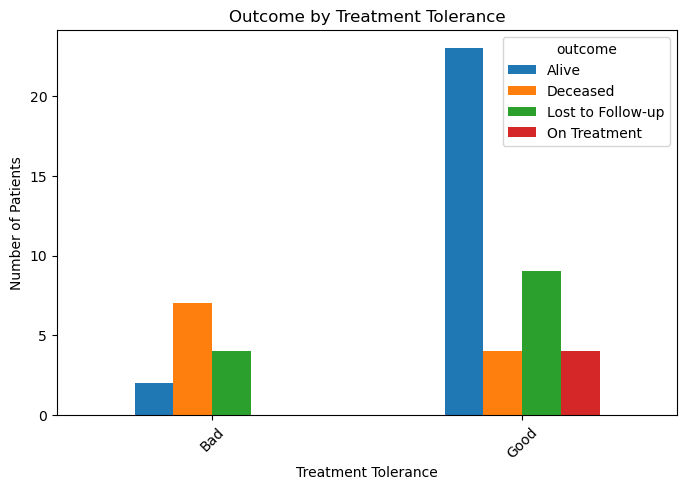

In [96]:
pd.crosstab(df["treatment_tolerance"], df["outcome"]).plot(
            kind="bar", figsize=(8,5))
plt.title("Outcome by Treatment Tolerance")
plt.xlabel("Treatment Tolerance")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Chi-square Tests of Independance
# Assess association between:
   - Ann Arbor Stage vs Treatment Response
   - Histology vs Treatment Response
   - Treatment Response vs Outcome
   - Treatment Tolerance vs Outcome

In [97]:
from scipy.stats import chi2_contingency
chi2, p, ddl, expected = chi2_contingency(pd.crosstab(df["ann_arbor_stage"], 
                                                      df["treatment_response"]))
print("Chi_square:", round(chi2, 2))
print("Degrees of freedom:", ddl)
print("p-value:", round(p, 2))

Chi_square: 15.31
Degrees of freedom: 9
p-value: 0.08


In [ ]:
A Chi-square test of independence was performed to assess the association between
Ann Arbor stage and Treatment Response. The association was not satistically
significant (χ2= 15.31, df= 9, p= 0.08). Therefore, treatment response did not
significantly differ across An Arbor Stages in this dataset.

In [98]:
chi2, p, ddl, expected = chi2_contingency(pd.crosstab(df["histology"], 
                                                      df["treatment_response"]))
print("Chi_square:", round(chi2, 2))
print("Degrees of freedom:", ddl)
print("p-value:", round(p, 2))

Chi_square: 2.13
Degrees of freedom: 6
p-value: 0.91


In [ ]:
A Chi-square test of independence was performed to assess the association between
histological subtype and Treatment Response. The association was not satistically
significant (χ2= 2.13, df= 6, p= 0.91). Therefore, treatment response did not
significantly differ among histological subtypes in this dataset.

In [99]:
chi2, p, ddl, expected = chi2_contingency(pd.crosstab(df["treatment_response"],
                                                     df["outcome"]))
print("Chi_square:", round(chi2, 3))
print("Degrees of freedom:", ddl)
print("p-value:", round(p, 3))

Chi_square: 31.047
Degrees of freedom: 9
p-value: 0.0


In [ ]:
A Chi-square test of independence was performed to assess the association between
treatment response and patient outcome. The association was satistically
significant (χ2= 31.05, df= 9, p < 0.001). Therefore, patient outcome differed
significantly according to treatment response in this dataset.

In [100]:
chi2, p, ddl, expected = chi2_contingency(pd.crosstab(df["treatment_tolerance"],
                                                     df["outcome"]))
print("Chi_square:", round(chi2, 3))
print("Degrees of freedom:", ddl)
print("p-value:", round(p, 3))

Chi_square: 14.351
Degrees of freedom: 3
p-value: 0.002


In [ ]:
A Chi-square test of independence was performed to assess the association between
treatment tolerance and patient outcome. The association was satistically
significant (χ2= 14.35, df= 3, p= 0.002). Therefore, patient outcome differed
significantly according to treatment tolerance in this dataset.

In [ ]:
# Logistic Regression Analysis
A multivariable logistic regression model was fitted to identify factors associated
with patient survival

In [116]:
df["histology"] = df["histology"].fillna("Others_lymphoma")

In [176]:
df["alive"] = df["outcome"].map({"Alive": 1, "Deceased": 0,
                                "On Treatment": 0,
                                "Lost to Follow-up": 0})

In [179]:
categories = {"sex": ["Female", "Male"],
             "ann_arbor_stage": ["I", "II", "III", "IV"],
              "treatment_response": ["Complete Response", "No Response",
                                    "Relapse", "Unknown"],
             "treatment_tolerance": ["Good", "Bad"],
             "histology": ["SLL", "DLBCL", "Others_lymphoma"]}
for col, cats in categories.items():
    df[col] = pd.Categorical(df[col], categories=cats)

In [180]:
x = df[["age", "sex", "ann_arbor_stage", "treatment_response",
        "histology", "treatment_tolerance"]]
y = df["alive"]

In [181]:
x = pd.get_dummies(x, drop_first=True)

In [182]:
x = x.astype(int)

In [183]:
import statsmodels.api as sm

x = sm.add_constant(x)
model = sm.Logit(y, x).fit()
print(model.summary())

         Current function value: 0.472201
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                  alive   No. Observations:                   69
Model:                          Logit   Df Residuals:                       57
Method:                           MLE   Df Model:                           11
Date:                Tue, 04 Aug 2026   Pseudo R-squ.:                  0.3060
Time:                        21:27:51   Log-Likelihood:                -32.582
converged:                      False   LL-Null:                       -46.947
Covariance Type:            nonrobust   LLR p-value:                  0.002500
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              3.9212      1.829      2.144      0.032       0.337       7.505
age  

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
A logistic regression analysis was performed to identify factors associated with
patient survival. 
The model included age, sex, Ann Arbor stage, histology, treatment response and 
treatment tolerance as predictor variables. 
The overall model was statistically significant (LLR p= 0.0025), indicating that
predictors collectively were associated with survival.
    
However, the model showed evidence of quasi-complete separation because all patients 
with "No Response" had a "non-survival" outcome (8/8). Consequently, the coefficient 
for this category was unstable. The estimated effect of this variable should be 
interpreted with caution.

In [184]:
import numpy as np
or_table = np.exp(model.conf_int())
or_table["OR"] = np.exp(model.params)
print(or_table)

                                       0            1            OR
const                           1.401179  1817.257174  5.046090e+01
age                             0.962597     1.044885  1.002897e+00
sex_Male                        0.064904     0.995754  2.542220e-01
ann_arbor_stage_II              0.006295     2.065095  1.140130e-01
ann_arbor_stage_III             0.003175     0.685355  4.664551e-02
ann_arbor_stage_IV              0.000422     0.612317  1.606905e-02
treatment_response_No Response  0.000000          inf  1.933332e-11
treatment_response_Relapse      0.055126     3.691083  4.510806e-01
treatment_response_Unknown      0.022296     1.026847  1.513112e-01
histology_DLBCL                 0.262994     4.204238  1.051518e+00
histology_Others_lymphoma       0.056525     6.574484  6.096066e-01
treatment_tolerance_Bad         0.054071     2.778554  3.876054e-01


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


In [ ]:
# Key findings
The overall logistic regression model was statistically significant (Likelihood Ratio
Test, p= 0.0025)
Male sex was associated with lower odds of survival
Advanced Ann Arbor stages (III and IV) were associated with lower odds of surivival
The coefficient for "No Response" could not be reliably estimated because of quasi-
complete separation